In [42]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# Import pandas for data manipulation and load the dataset from Google Drive
import pandas as pd

file_path = '/content/drive/My Drive/Predective Analytics SEM-6/adult.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Dataset '{file_path}' loaded successfully. First 5 rows:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset '/content/drive/My Drive/Predective Analytics SEM-6/adult.csv' loaded successfully. First 5 rows:
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4            

In [44]:
# Print the initial shape of the dataset (rows, columns)
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 48842 rows and 15 columns.


In [45]:
# Import numpy for numerical operations
import numpy as np

# Replace '?' and ' ?' with NaN across the entire DataFrame to handle missing values consistently
df.replace('?', np.nan, inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace(' ?', np.nan, regex=False)

print("First 5 rows after replacing '?' with NaN:")
print(df.head())

print("\nTotal missing values after replacement:")
print(df.isnull().sum())

First 5 rows after replacing '?' with NaN:
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18        NaN  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0

In [46]:
# Impute missing values: use mode for categorical columns and median for numerical columns
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [47]:
# Display the first 5 rows and verify that all missing values have been handled
print(df.head())
print(df.isnull().sum())

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18    Private  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4     Prof-specialty    Own-child  White  Female             0             0   

   hours-per-week native-country incom

In [48]:
# Drop duplicate rows from the dataset
df.drop_duplicates(inplace=True)

In [49]:
# Print the shape of the dataset after dropping duplicates
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 48789 rows and 15 columns.


In [50]:
# Clean and encode the 'income' target variable: map '<=50K' to 0 and '>50K' to 1
df['income'] = df['income'].str.strip()
df['income'] = df['income'].map({'<=50K':0, '>50K':1})

In [51]:
# Display the first 5 rows to show the encoded 'income' column
print(df.head())

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18    Private  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4     Prof-specialty    Own-child  White  Female             0             0   

   hours-per-week native-country  inco

In [52]:
# Apply one-hot encoding to all categorical columns and drop the first category to avoid multicollinearity
df = pd.get_dummies(df, drop_first=True)

In [53]:
# Display the first 5 rows of the DataFrame after one-hot encoding
print(df.head())

   age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week  \
0   25  226802                7             0             0              40   
1   38   89814                9             0             0              50   
2   28  336951               12             0             0              40   
3   44  160323               10          7688             0              40   
4   18  103497               10             0             0              30   

   income  workclass_Local-gov  workclass_Never-worked  workclass_Private  \
0       0                False                   False               True   
1       0                False                   False               True   
2       1                 True                   False              False   
3       1                False                   False               True   
4       0                False                   False               True   

   ...  native-country_Portugal  native-country_Puerto-Rico  \

In [54]:
# Import train_test_split for splitting data
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop("income", axis=1)
y = df["income"]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Initialize and fit the scaler on the training data, then transform both train and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

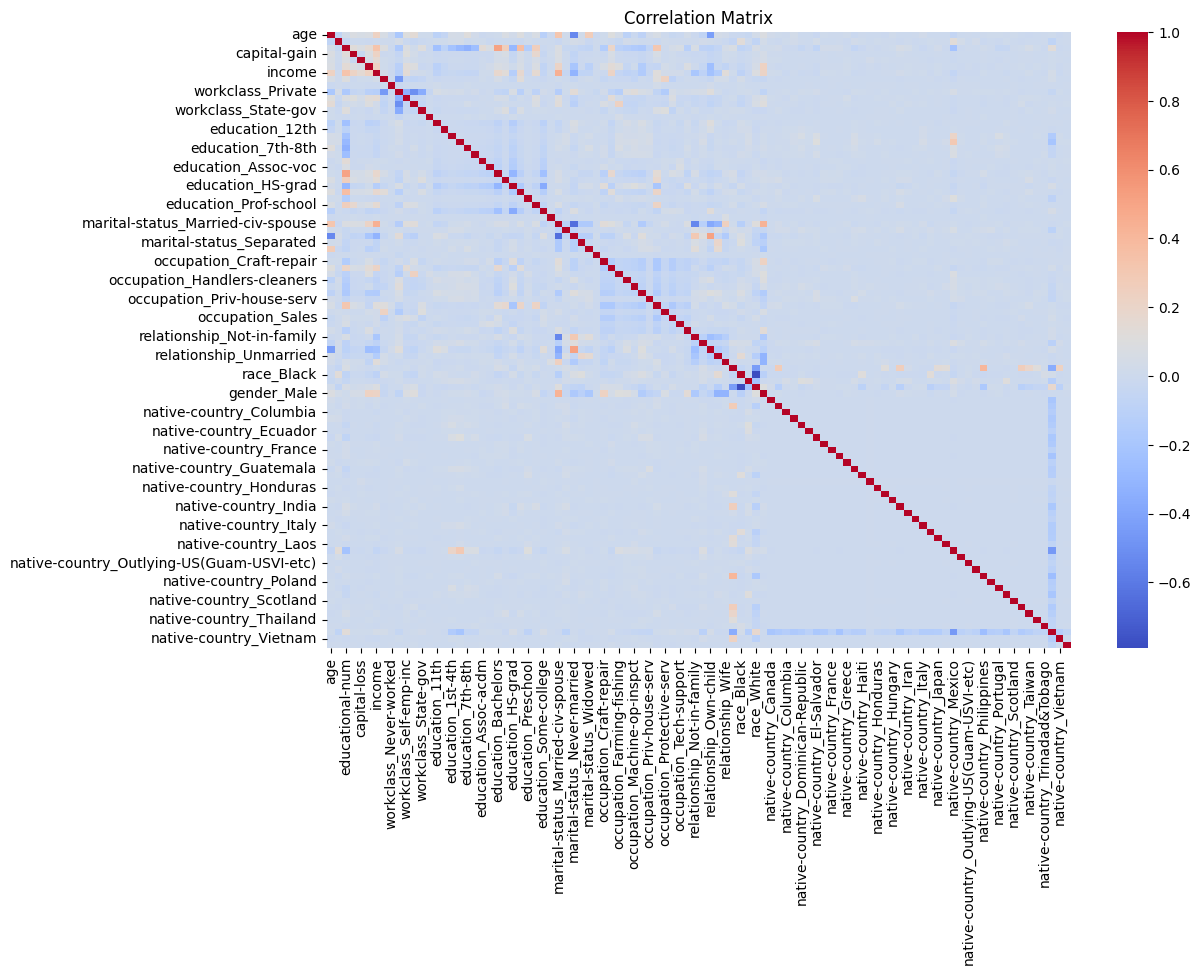

In [56]:
# Import libraries for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Create and display a heatmap of the correlation matrix for the DataFrame
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [57]:
# Import DecisionTreeClassifier and train a model using 'entropy' as the criterion
from sklearn.tree import DecisionTreeClassifier

dt_entropy = DecisionTreeClassifier(criterion='entropy')
dt_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [58]:
# Train another Decision Tree model using 'gini' as the criterion
dt_gini = DecisionTreeClassifier(criterion='gini')
dt_gini.fit(X_train, y_train)

DecisionTreeClassifier()

In [59]:
# Import GaussianNB and train a Naive Bayes model using scaled data
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

GaussianNB()

In [60]:
# Import KNeighborsClassifier and train a KNN model with 5 neighbors using scaled data
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [61]:
# Import SVC and train a Support Vector Machine model with a 'linear' kernel using scaled data
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [62]:
# Train another Support Vector Machine model with an 'rbf' (Radial Basis Function) kernel using scaled data
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

SVC()

In [63]:
# Import necessary metrics for model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

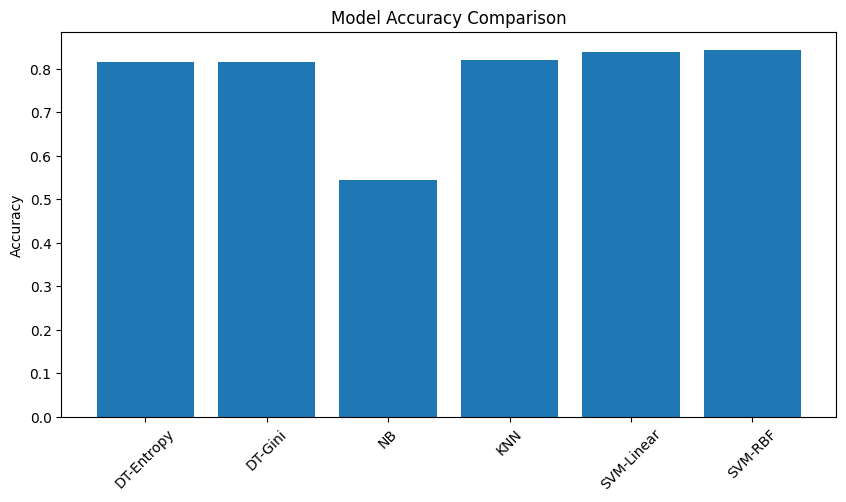

In [64]:
# Define model names and collect accuracy scores for plotting
models = ['DT-Entropy','DT-Gini','NB','KNN','SVM-Linear','SVM-RBF']
accuracy = [acc1, acc2, acc3, acc4, acc5, acc6]

# Create and display a bar chart to compare the accuracy of different models
plt.figure(figsize=(10,5))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

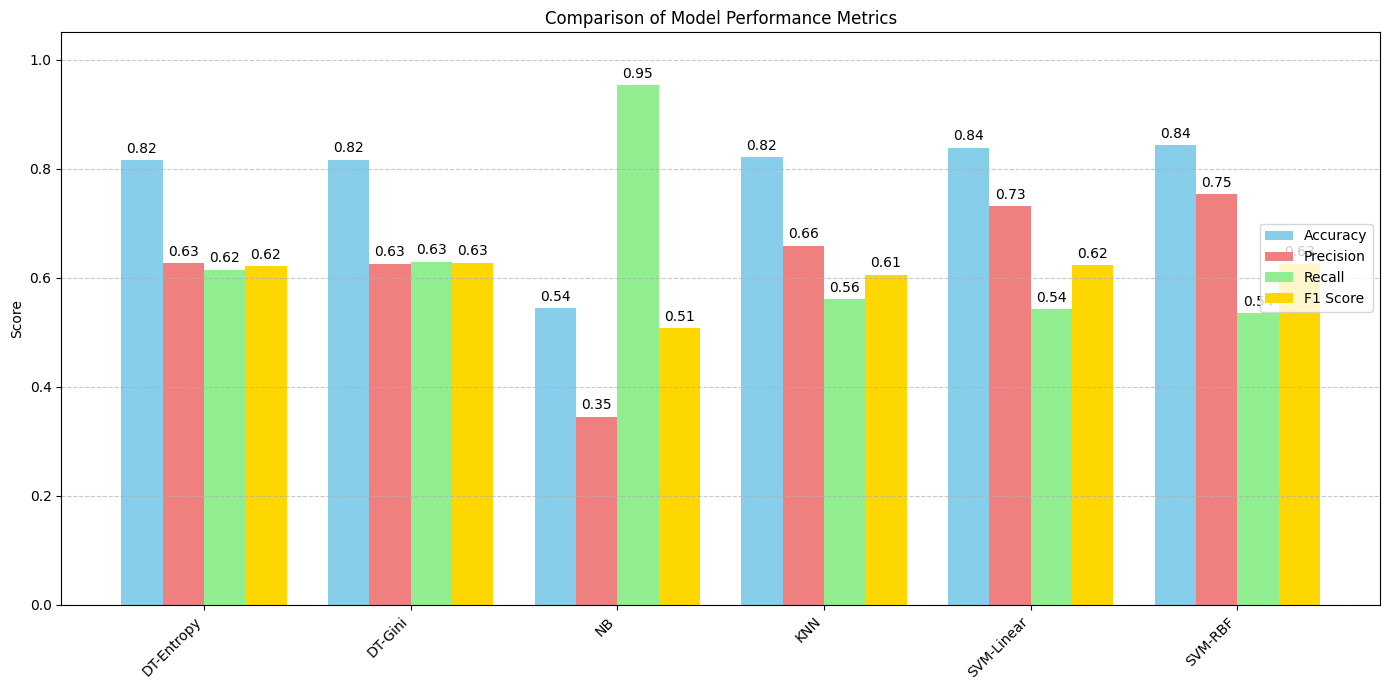

In [65]:
# Import libraries for plotting
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting all performance metrics
models = ['DT-Entropy','DT-Gini','NB','KNN','SVM-Linear','SVM-RBF']
accuracy_scores = [acc1, acc2, acc3, acc4, acc5, acc6]
precision_scores = [prec1, prec2, prec3, prec4, prec5, prec6]
recall_scores = [rec1, rec2, rec3, rec4, rec5, rec6]
f1_scores = [f11, f12, f13, f14, f15, f16]

# Set up the plot for grouped bar chart
x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 7))

# Plotting each metric as a group of bars for each model
rects1 = ax.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, precision_scores, width, label='Precision', color='lightcoral')
rects3 = ax.bar(x + 0.5*width, recall_scores, width, label='Recall', color='lightgreen')
rects4 = ax.bar(x + 1.5*width, f1_scores, width, label='F1 Score', color='gold')

# Add labels, title, and customize x-axis ticks
ax.set_ylabel('Score')
ax.set_title('Comparison of Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.5))
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Function to attach a text label above each bar, displaying its height
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Apply autolabel to all bar groups
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.show()

The grouped bar chart provides a detailed view of each model's performance across different metrics. Now, let's look at the confusion matrix for the best-performing model, SVM-RBF, to understand its predictions in more detail.

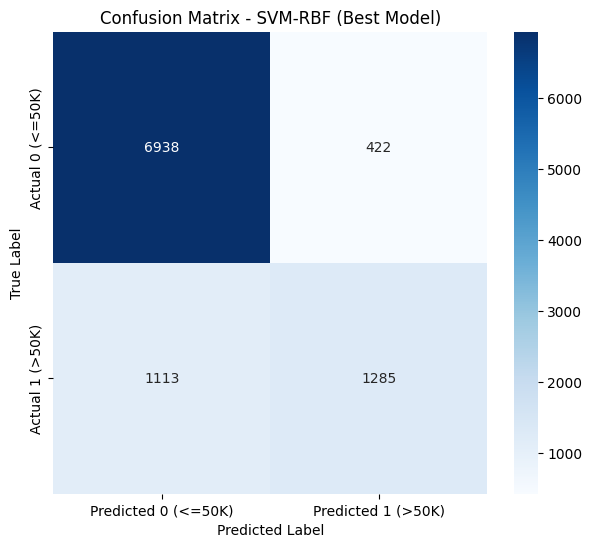

In [66]:
# Import libraries for confusion matrix and plotting
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict using the best model (SVM-RBF) on the scaled test data
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

# Generate the confusion matrix for SVM-RBF
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)

# Plot the confusion matrix as a heatmap for better visualization
plt.figure(figsize=(7, 6))
sns.heatmap(cm_svm_rbf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (<=50K)', 'Predicted 1 (>50K)'],
            yticklabels=['Actual 0 (<=50K)', 'Actual 1 (>50K)'])
plt.title('Confusion Matrix - SVM-RBF (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [67]:
# Define a function to evaluate a model and display its performance metrics and confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name):

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate various performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print the metrics
    print(f"----- {model_name} -----")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    # Generate and plot the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Return the metrics
    return acc, prec, rec, f1

----- DT-Entropy -----
Accuracy: 0.8190202910432466
Precision: 0.6345826235093697
Recall: 0.6213511259382819
F1 Score: 0.627897176569743


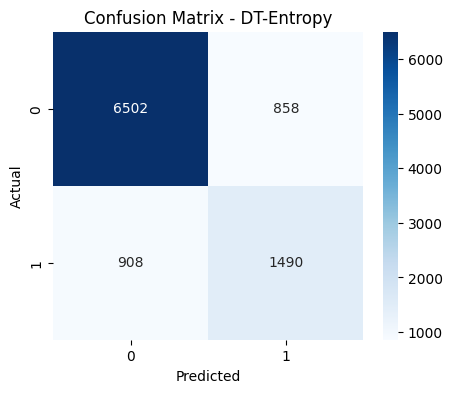

In [68]:
# Evaluate the Decision Tree model (Entropy) and store its metrics
acc1, prec1, rec1, f11 = evaluate_model(dt_entropy, X_test, y_test, "DT-Entropy")

----- DT-Gini -----
Accuracy: 0.8161508505841361
Precision: 0.6274261603375527
Recall: 0.6201000834028357
F1 Score: 0.6237416107382551


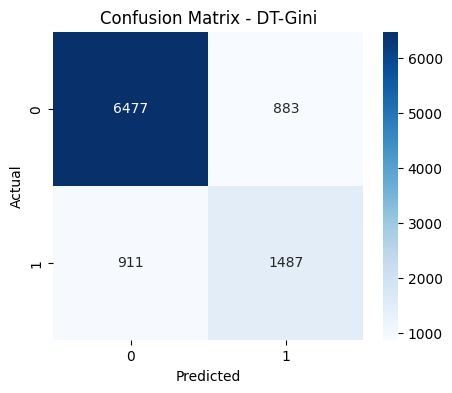

In [69]:
# Evaluate the Decision Tree model (Gini) and store its metrics
acc2, prec2, rec2, f12 = evaluate_model(dt_gini, X_test, y_test, "DT-Gini")

----- Naive Bayes -----
Accuracy: 0.5445788071326091
Precision: 0.34542157751586583
Recall: 0.9532944120100083
F1 Score: 0.5070984915705412


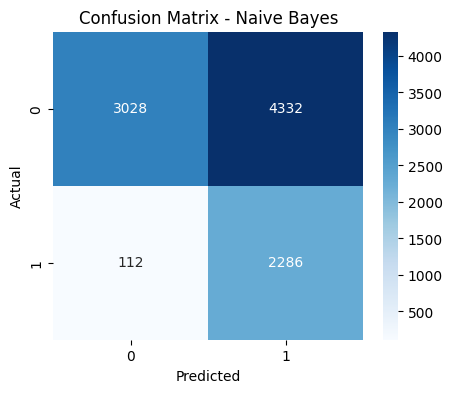

In [70]:
# Evaluate the Naive Bayes model using scaled data and store its metrics
acc3, prec3, rec3, f13 = evaluate_model(nb, X_test_scaled, y_test, "Naive Bayes")

----- KNN -----
Accuracy: 0.8206599713055954
Precision: 0.6588235294117647
Recall: 0.5604670558798999
F1 Score: 0.6056782334384858


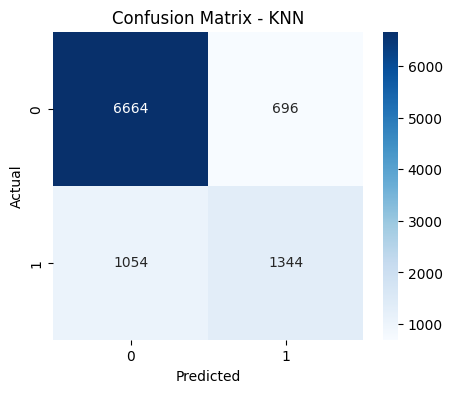

In [71]:
# Evaluate the KNN model using scaled data and store its metrics
acc4, prec4, rec4, f14 = evaluate_model(knn, X_test_scaled, y_test, "KNN")

----- SVM-Linear -----
Accuracy: 0.8387989342078295
Precision: 0.7318718381112985
Recall: 0.5429524603836531
F1 Score: 0.6234139334450562


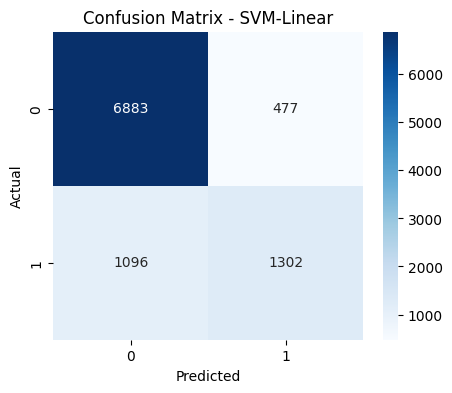

In [72]:
# Evaluate the SVM-Linear model using scaled data and store its metrics
acc5, prec5, rec5, f15 = evaluate_model(svm_linear, X_test_scaled, y_test, "SVM-Linear")

----- SVM-RBF -----
Accuracy: 0.842693174830908
Precision: 0.7527826596367897
Recall: 0.5358632193494579
F1 Score: 0.6260657734470159


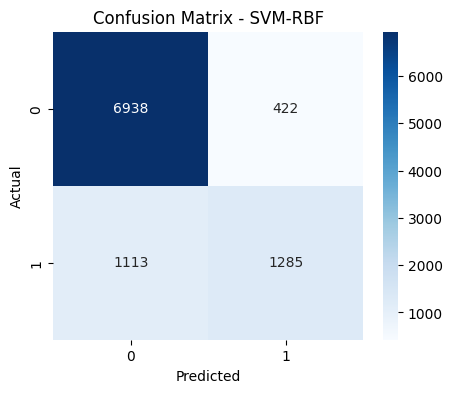

In [73]:
# Evaluate the SVM-RBF model using scaled data and store its metrics
acc6, prec6, rec6, f16 = evaluate_model(svm_rbf, X_test_scaled, y_test, "SVM-RBF")